In [1]:
import pandas as pd
pd.options.display.max_rows = 999
pd.options.display.max_columns = 999
import requests 
import os
import numpy as np
from pathlib import Path
import glob, zipfile, io
#import pyarrow as pa
#import pyarrow.parquet as pq



In [2]:
# Definition des dossiers
folder_entries = Path("Patricia-Promise-Immo","data")
base_dir = Path().resolve().parents[1]
data_dir = base_dir/folder_entries
if not data_dir.exists():
    data_dir.mkdir(parents=True)
print(f"Data directory is set to : {data_dir}")

Data directory is set to : D:\ProjectFolderDevAI_2025-2026\Immo_project\Patricia-Promise-Immo\data


In [3]:
# Liste des fichiers à télécharger par année via leurs URLs
DOWNLOADs_ = [
    {
        'url' : 'https://static.data.gouv.fr/resources/demandes-de-valeurs-foncieres/20251018-234902/valeursfoncieres-2025-s1.txt.zip',
        'year' : '2025'
    },
    {
        'url' : 'https://static.data.gouv.fr/resources/demandes-de-valeurs-foncieres/20251018-234857/valeursfoncieres-2024.txt.zip',
        'year' : '2024'
    },
    {
        'url' : 'https://static.data.gouv.fr/resources/demandes-de-valeurs-foncieres/20251018-234851/valeursfoncieres-2023.txt.zip',
        'year' : '2023'
    },
    {
        'url' : 'https://static.data.gouv.fr/resources/demandes-de-valeurs-foncieres/20251018-234844/valeursfoncieres-2022.txt.zip',
        'year' : '2022'
    },
    {
        'url' : 'https://static.data.gouv.fr/resources/demandes-de-valeurs-foncieres/20251018-234836/valeursfoncieres-2021.txt.zip',
        'year' : '2021'
    },
    {
        'url' : 'https://static.data.gouv.fr/resources/demandes-de-valeurs-foncieres/20251018-234831/valeursfoncieres-2020-s2.txt.zip',
        'year' : '2020'
    }
    
    ]

# Téléchargement des fichiers par année
for immo_file in DOWNLOADs_ :
    response = requests.get(immo_file['url'], stream=True) #Stream = True afin d'éviter de tout charger en mémoire
    
    # Création du dossier 'raw' s'il n'existe pas pour stocker les fichiers téléchargés
    raw_dir = data_dir/"raw"
    if not raw_dir.exists():
        raw_dir.mkdir(parents=True)
        
    # Enregistrement du fichier par itérations
    with open(f"{raw_dir}/immo_entries_{immo_file['year']}.txt.zip", 'wb') as file:
        for chunk in response.iter_content(chunk_size=10_000):
            file.write(chunk)

print("Téléchargement terminé.")

Téléchargement terminé.


In [12]:
# Liste des fichiers téléchargés
all_immo_files = os.listdir(raw_dir)
print("Fichiers téléchargés :")
for f in all_immo_files:
    print(f" - {f}")    

Fichiers téléchargés :
 - immo_entries_2020.txt.zip
 - immo_entries_2021.txt.zip
 - immo_entries_2022.txt.zip
 - immo_entries_2023.txt.zip
 - immo_entries_2024.txt.zip
 - immo_entries_2025.txt.zip


In [13]:
csv_dir = data_dir/"raw_csv"
if not csv_dir.exists():
     csv_dir.mkdir(parents=True)
print(csv_dir)  

D:\ProjectFolderDevAI_2025-2026\Immo_project\Patricia-Promise-Immo\data\raw_csv


In [11]:
# Récupération des fichiers .txt.zip pour conversion en .csv
files_texts = sorted(glob.glob("*.txt.zip", root_dir=raw_dir))
print(files_texts)

CHUNK = 200_000
# Definition du chemin des fichiers qui seront convertis en .csv
for f in files_texts:
    out_name = Path(f).name.replace(".txt.zip", ".csv") # On recupère juste le nom du futur fichier
    out_path = csv_dir/out_name

    # Vérification du chemin out_path
    if out_path.exists():
        out_path.unlink() # Supprime le ficchier qui existe déjà avant de créer un nouveau
    
    # Lire le .txt.zip compréssé à l'interieur du .zip
    zip_path = raw_dir/f
    with zipfile.ZipFile(zip_path, "r") as zf:
       names=[n for n in zf.namelist() if n.lower().endswith(".txt")]
       if not names:
            #raise ValueError("Aucun fichier .txt dans le ", f)
            continue
       first = True
       with zf.open(names[0], "r") as fb:
           stream_txt = io.TextIOWrapper(fb, encoding="utf-8", errors="ignore")
           # Convertir chaque élément en DataFrame pandas
           for chunk in pd.read_csv(stream_txt, sep="|", chunksize= CHUNK,  low_memory=False, decimal=',', dtype={'Code postal':str, 'Valeur fonciere':np.float64}, on_bad_lines='skip'):
                # Sauvegarde du DataFrame eb fichier .csv
                chunk.to_csv(out_path, index=False, mode = "a", header= first)
                first = False # Après la première écriture du header, il faut plus écrire l'entête et on le désactive pour les chunhs suivants avcec first = False

print("Extraction des fichiers .csv terminés.")

['immo_entries_2020.txt.zip', 'immo_entries_2021.txt.zip', 'immo_entries_2022.txt.zip', 'immo_entries_2023.txt.zip', 'immo_entries_2024.txt.zip', 'immo_entries_2025.txt.zip']
Extraction des fichiers .csv terminés.


In [14]:
# Exploration d'un fichier téléchargé et conversion en DataFrame 
data_path = data_dir/"raw_csv"
raw_path = data_path/"immo_entries_2025.csv"
print(raw_path)
df = pd.read_csv(f"{raw_path}",low_memory=False, sep=',')
df

D:\ProjectFolderDevAI_2025-2026\Immo_project\Patricia-Promise-Immo\data\raw_csv\immo_entries_2025.csv


,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Date mutation,Nature mutation,Valeur fonciere,No voie,B/T/Q,Type de voie,Code voie,Voie,Code postal,Commune,Code departement,Code commune,Prefixe de section,Section,No plan,No Volume,1er lot,Surface Carrez du 1er lot,2eme lot,Surface Carrez du 2eme lot,3eme lot,Surface Carrez du 3eme lot,4eme lot,Surface Carrez du 4eme lot,5eme lot,Surface Carrez du 5eme lot,Nombre de lots,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,07/01/2025,Vente,468000.0,NaN,NaN,NaN,B078,FARGES,1550.0,FARGES,1,158,NaN,B,815,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,J,NaN,78.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,07/01/2025,Vente,468000.0,454.0,NaN,RUE,0090,DE LA REPUBLIQUE,1550.0,FARGES,1,158,NaN,B,910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,NaN,111.0,5.0,S,NaN,133.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,07/01/2025,Vente,468000.0,454.0,NaN,RUE,0090,DE LA REPUBLIQUE,1550.0,FARGES,1,158,NaN,B,910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3.0,Dépendance,NaN,0.0,0.0,S,NaN,133.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,06/01/2025,Vente,180000.0,NaN,NaN,NaN,B158,LE VILLAGE,1200.0,MONTANGES,1,257,NaN,AC,334,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,S,NaN,46.0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,06/01/2025,Vente,180000.0,NaN,NaN,NaN,B158,LE VILLAGE,1200.0,MONTANGES,1,257,NaN,AC,338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,J,NaN,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1387072,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,27/06/2025,Vente,550000.0,84.0,NaN,RUE,9679,VERGNIAUD,75013.0,PARIS 13,75,113,NaN,DK,8,NaN,376,NaN,421,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2.0,Appartement,NaN,61.0,3.0,NaN,NaN,NaN
1387073,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,27/06/2025,Vente,550386.1,24.0,NaN,RUE,7621,DE PONTOISE,75005.0,PARIS 05,75,105,NaN,AC,14,NaN,4,NaN,42,48.27,NaN,NaN,NaN,NaN,NaN,NaN,2,2.0,Appartement,NaN,47.0,2.0,NaN,NaN,NaN
1387074,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,27/06/2025,Vente,550386.1,24.0,NaN,RUE,7621,DE PONTOISE,75005.0,PARIS 05,75,105,NaN,AC,14,NaN,4,NaN,42,48.27,NaN,NaN,NaN,NaN,NaN,NaN,2,3.0,Dépendance,NaN,0.0,0.0,NaN,NaN,NaN
1387075,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,25/06/2025,Vente,24417580.0,NaN,NaN,NaN,NaN,NaN,NaN,PARIS 15,75,115,NaN,ES,46,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
"""parquet_path= interim_dir/"all_immo_entries.parquet"
print(parquet_path)

writer = None

for index, chunk in enumerate(pd.read_csv(f"{output_path}", chunksize=10_000)):
    table = pa.Table.from_pandas(chunk, preserve_index=False)
    
    # Initialise le writer une seule fois avec le schéma du premier chunk
    if writer is None:
        writer = pq.ParquetWriter(parquet_path, schema=table.schema, compression="snappy")
    
    # Écrit le chunk courant
    writer.write_table(table)

# Ferme le writer à la fin
if writer is not None:
    writer.close()"""



In [ ]:
!pip install missingno

<Axes: >

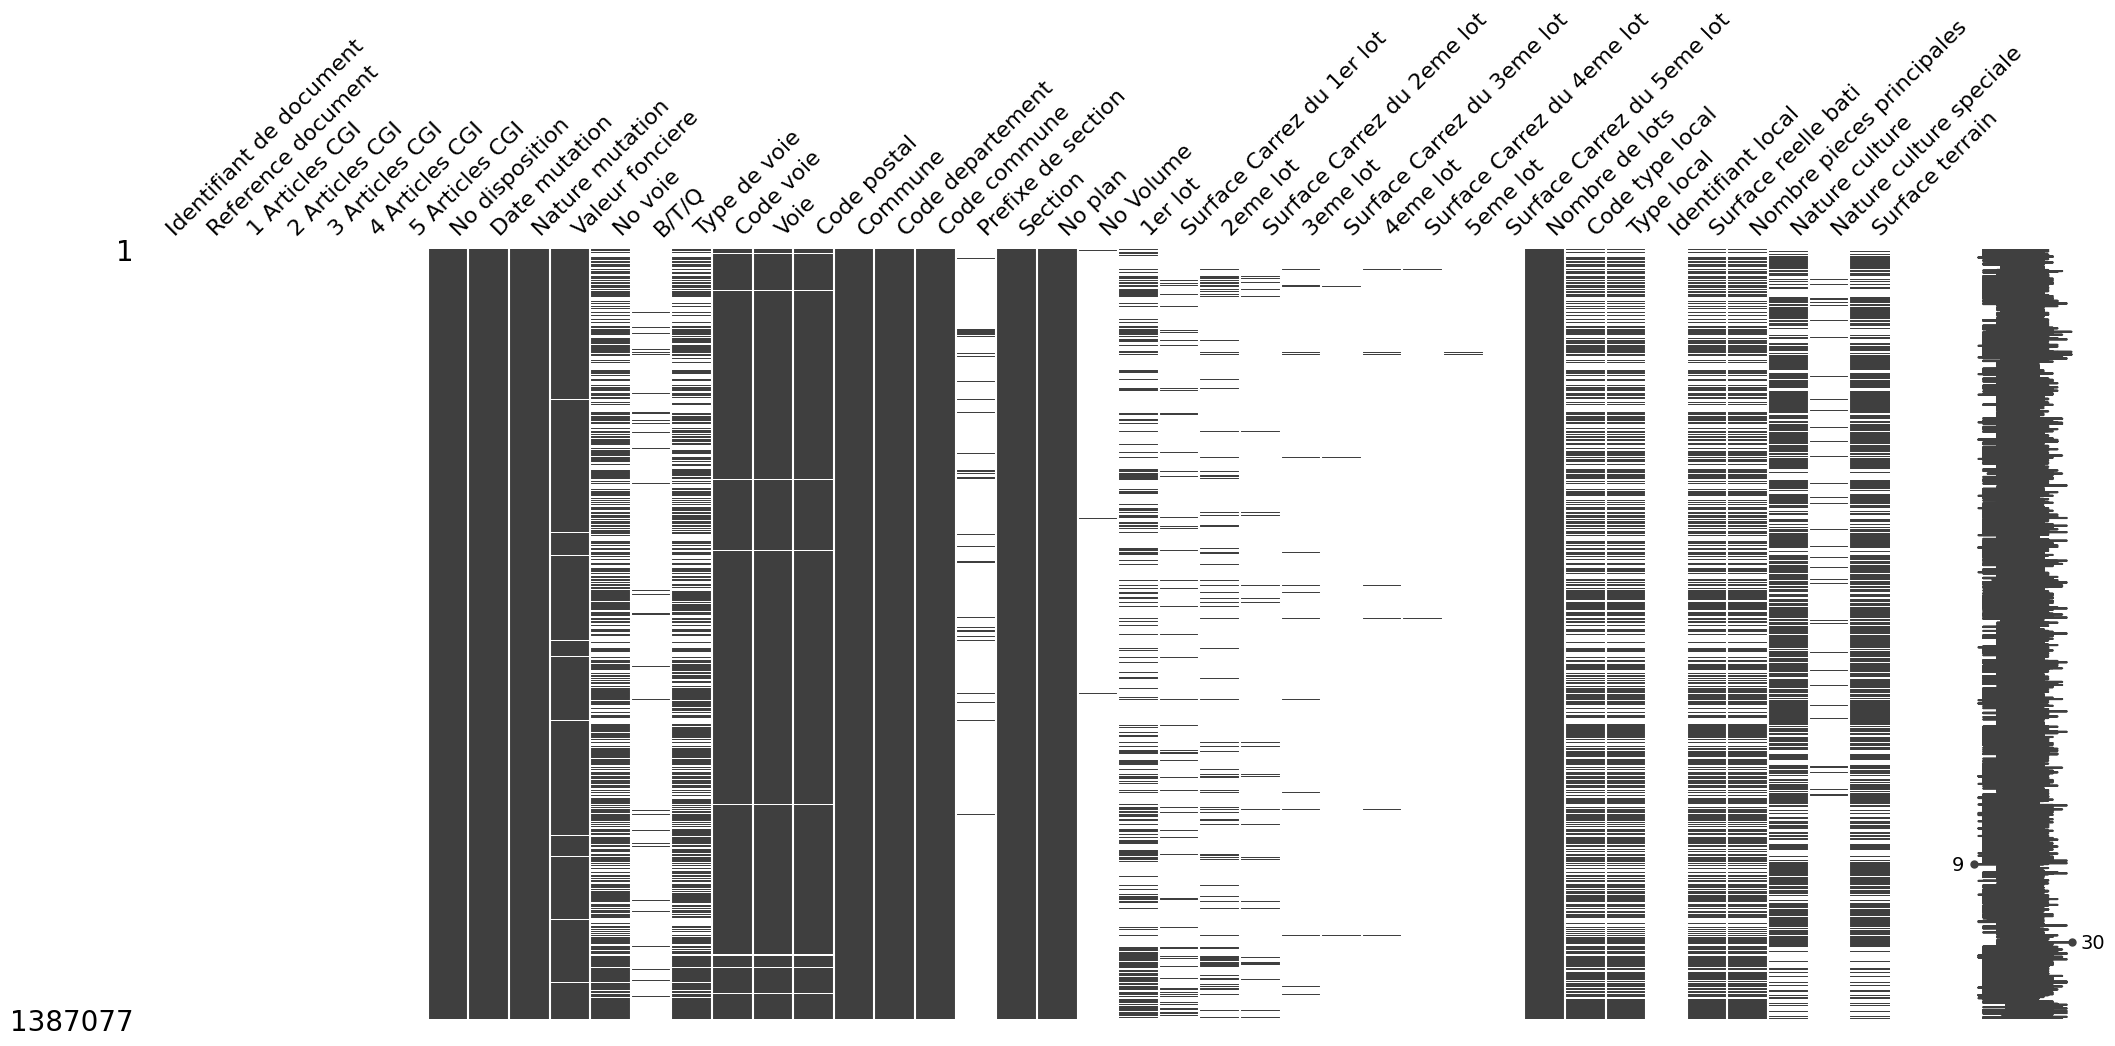

In [15]:
# Matrice des valeurs manquantes
import missingno as msno
msno.matrix(df)